# Model Evaluation - Approach A

**Team Member:** Annalena Salchegger

This notebook evaluates the trained keypoint detection model on the test set.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import json

## Configuration

In [ ]:
DATA_DIR      = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = DATA_DIR / 'processed'
LABELS_DIR    = PROCESSED_DIR / 'labels_keypoints'
GT_EXPORT = DATA_DIR / 'ground_truth' / 'labels' / 'all_annotations_merged.json'
MODEL_PATH = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model_A.pth')

# test split
TEST_IMG = DATA_DIR / 'images' / 'test'
TEST_LABELS = LABELS_DIR / 'test'

# device and hyperparameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
BATCH_SIZE = 16

## Load Ground Truth

In [ ]:
HEAD_LABEL = 'Head'
TAIL_LABEL = 'Tail'

# load and parse GT annotations
def load_ground_truth(gt_export_path):
    if not gt_export_path.exists():
        print(f"ERROR: GT file not found: {gt_export_path}")
        return {}

    with open(gt_export_path) as f:
        data = json.load(f)

    gt = {}
    for item in data:
        img_name = Path(item.get('data', {}).get('img', item.get('file_upload', ''))).stem.split('-', 1)[-1]

        pairs = []
        for ann in item['annotations']:
            pending_head = None
            all_tails = [
                (r['value']['x'] / 100.0, r['value']['y'] / 100.0)
                for r in ann['result']
                if r['value']['keypointlabels'][0] == 'Tail'
            ]

            for r in ann['result']:
                label = r['value']['keypointlabels'][0]
                x = r['value']['x'] / 100.0
                y = r['value']['y'] / 100.0

                if label == 'Head':
                    pending_head = (x, y)
                elif label == 'Tail' and pending_head is not None:
                    pairs.append({'Head': pending_head, 'Tail': (x, y)})
                    pending_head = None

            # if head had no following tail, pair by nearest remaining tail
            if pending_head is not None:
                used_tails = {p['Tail'] for p in pairs}
                remaining = [t for t in all_tails if t not in used_tails]
                if remaining:
                    best = min(remaining,
                               key=lambda t: (pending_head[0]-t[0])**2 + (pending_head[1]-t[1])**2)
                    pairs.append({'Head': pending_head, 'Tail': best})

        if pairs:
            gt[img_name] = pairs

    print(f"Loaded {len(gt)} images with GT annotations")
    print(f"Total annotated animals: {sum(len(p) for p in gt.values())}")
    return gt

gt = load_ground_truth(GT_EXPORT)

Loaded 154 images with GT annotations
Total annotated animals: 360


## Dataset

In [ ]:
# load images and keypoint labels
class KeypointDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        
        self.image_files = sorted(list(self.img_dir.glob('*.jpg')))
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        label_path = self.label_dir / f"{img_path.stem}.txt"
        
        img = Image.open(img_path).convert('RGB')
        
        all_keypoints = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) >= 11:
                        all_keypoints.append([
                            float(parts[5]),
                            float(parts[6]),
                            float(parts[8]),
                            float(parts[9]),
                        ])
        
        if all_keypoints:
            keypoints = torch.tensor(all_keypoints, dtype=torch.float32).mean(dim=0)
        else:
            keypoints = torch.zeros(4, dtype=torch.float32)
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, keypoints, img_path.name


## Load Model

In [ ]:
# simple model definition
class KeypointModel(nn.Module):
    def __init__(self, num_keypoints=2):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_keypoints * 2)
        )

    def forward(self, x):
        return torch.sigmoid(self.backbone(x))

# load model
print("\nLoading model...")
model = KeypointModel(2).to(DEVICE)
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    print(f"Loaded model from {MODEL_PATH}")
else:
    print(f"No saved model found at {MODEL_PATH}")

model.eval()


Loading model...


Loaded model from /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model_A.pth


KeypointModel(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): C

## Load Test Data

In [ ]:
# transforms and dataloader for test set
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_dataset = KeypointDataset(TEST_IMG, TEST_LABELS, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test samples: {len(test_dataset)}")

Test samples: 2483


## Load Boxes


In [ ]:
# return list of dicts with bbox fields for every line in a label file
def load_all_bboxes(label_path):
    bboxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            bboxes.append({
                'line': line.strip(),
                'cx': float(parts[1]),
                'cy': float(parts[2]),
                'bw': float(parts[3]),
                'bh': float(parts[4]),
            })
    return bboxes

# compute pixel crop coords for a bbox dict
def compute_crop(bbox, orig_w, orig_h, pad=0.5, min_frac=0.10):
    cx, cy = bbox['cx'], bbox['cy']
    bw, bh = bbox['bw'], bbox['bh']

    x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
    y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
    x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
    y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

    min_crop_px = orig_w * min_frac
    if (x2 - x1) < min_crop_px:
        mid_x = (x1 + x2) / 2
        x1 = max(0, mid_x - min_crop_px / 2)
        x2 = min(orig_w, mid_x + min_crop_px / 2)

    min_crop_py = orig_h * min_frac
    if (y2 - y1) < min_crop_py:
        mid_y = (y1 + y2) / 2
        y1 = max(0, mid_y - min_crop_py / 2)
        y2 = min(orig_h, mid_y + min_crop_py / 2)

    return x1, y1, x2, y2


def match_predictions_to_gt(predictions, gt_pairs):
    """
    Greedily matches each predicted animal to its nearest GT pair by
    comparing the predicted head/tail midpoint to the GT midpoint.
    predictions: list of {'pred_head': (x,y), 'pred_tail': (x,y)}  - pixel coords
    gt_pairs:    list of {'Head': (nx,ny), 'Tail': (nx,ny)}         - normalised coords
    orig_w, orig_h: used to convert GT to pixels inside the caller
    Returns list of (pred, gt_pair_or_None) tuples.
    """
    matched = []
    used_gt = set()
    for pred in predictions:
        pred_mid = np.array([
            (pred['pred_head'][0] + pred['pred_tail'][0]) / 2,
            (pred['pred_head'][1] + pred['pred_tail'][1]) / 2,
        ])
        best_dist, best_idx = float('inf'), None
        for i, gt_pair in enumerate(gt_pairs):
            if i in used_gt:
                continue
            gt_mid = np.array([
                (gt_pair['Head'][0] + gt_pair['Tail'][0]) / 2,
                (gt_pair['Head'][1] + gt_pair['Tail'][1]) / 2,
            ])
            d = np.linalg.norm(pred_mid - gt_mid)
            if d < best_dist:
                best_dist, best_idx = d, i
        if best_idx is not None:
            matched.append((pred, gt_pairs[best_idx]))
            used_gt.add(best_idx)
        else:
            matched.append((pred, None))
    return matched

In [ ]:
def find_best_bbox(label_path, ref_x, ref_y):
    """
    returns the bbox line whose center is closest to (ref_x, ref_y)
    ref_x / ref_y are normalised [0,1] coordinates (e.g. midpoint of GT head+tail).
    """
    best_line, best_dist = None, float('inf')
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cx, cy = float(parts[1]), float(parts[2])
            d = np.sqrt((cx - ref_x) ** 2 + (cy - ref_y) ** 2)
            if d < best_dist:
                best_dist = d
                best_line = line.strip()
    return best_line

## Evaluation on Ground Truth

In [ ]:
# main evaluation loop on real GT images
def evaluate_on_real_gt(model, gt, device, img_size=IMG_SIZE):
    model.eval()

    total_head_error = 0
    total_tail_error = 0
    num_animals = 0
    errors_per_animal = []

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    print("\nEvaluating on real ground truth images:")
    print("-" * 60)

    with torch.no_grad():
        for img_name, gt_pairs in gt.items():
            img_path = None
            for split in ['test', 'val', 'train']:
                p = DATA_DIR / 'images' / split / f"{img_name}.jpg"
                if p.exists():
                    img_path = p
                    break
            if img_path is None:
                continue

            label_path = None
            for split in ['test', 'val', 'train']:
                p = LABELS_DIR / split / f"{img_name}.txt"
                if p.exists():
                    label_path = p
                    break
            if label_path is None:
                continue

            img = Image.open(img_path).convert('RGB')
            orig_w, orig_h = img.size

            bboxes = load_all_bboxes(label_path)
            if not bboxes:
                continue

            # run model on every bbox crop
            predictions = []
            for bbox in bboxes:
                x1, y1, x2, y2 = compute_crop(bbox, orig_w, orig_h)
                crop_w, crop_h = x2 - x1, y2 - y1
                img_crop = img.crop((x1, y1, x2, y2))
                img_tensor = transform(img_crop).unsqueeze(0).to(device)
                output = model(img_tensor)
                pred = output[0].cpu().numpy()
                predictions.append({
                    'pred_head': (pred[0] * crop_w + x1, pred[1] * crop_h + y1),
                    'pred_tail': (pred[2] * crop_w + x1, pred[3] * crop_h + y1),
                    'crop': (x1, y1, x2, y2),
                    'pred_norm': pred,
                })

            # convert GT to pixel coords for matching
            gt_pairs_px = [{
                'Head': (p['Head'][0] * orig_w, p['Head'][1] * orig_h),
                'Tail': (p['Tail'][0] * orig_w, p['Tail'][1] * orig_h),
            } for p in gt_pairs]

            matched = match_predictions_to_gt(predictions, gt_pairs_px)

            image_errors = []
            for pred, gt_pair in matched:
                if gt_pair is None:
                    continue

                x1, y1, x2, y2 = pred['crop']
                crop_w, crop_h = x2 - x1, y2 - y1

                true_head_crop = np.array([
                    max(0.0, min(1.0, (gt_pair['Head'][0] - x1) / crop_w)),
                    max(0.0, min(1.0, (gt_pair['Head'][1] - y1) / crop_h)),
                ])
                true_tail_crop = np.array([
                    max(0.0, min(1.0, (gt_pair['Tail'][0] - x1) / crop_w)),
                    max(0.0, min(1.0, (gt_pair['Tail'][1] - y1) / crop_h)),
                ])

                p_norm = pred['pred_norm']
                pred_head_crop = p_norm[:2]
                pred_tail_crop = p_norm[2:4]

                head_err_normal  = np.linalg.norm(pred_head_crop - true_head_crop)
                tail_err_normal  = np.linalg.norm(pred_tail_crop - true_tail_crop)
                head_err_flipped = np.linalg.norm(pred_head_crop - true_tail_crop)
                tail_err_flipped = np.linalg.norm(pred_tail_crop - true_head_crop)

                if (head_err_flipped + tail_err_flipped) < (head_err_normal + tail_err_normal):
                    head_error, tail_error = head_err_flipped, tail_err_flipped
                else:
                    head_error, tail_error = head_err_normal, tail_err_normal

                total_head_error += head_error
                total_tail_error += tail_error
                num_animals += 1
                avg_error = (head_error + tail_error) / 2
                errors_per_animal.append(avg_error)
                image_errors.append(avg_error)

            status_line = " ".join("✅" if e < 0.1 else "⚠️" for e in image_errors)
            n_pred = len(predictions)
            n_gt   = len(gt_pairs)
            print(f"{status_line} {img_name}: {n_pred} bbox(es), {n_gt} GT pair(s)")

    if num_animals > 0:
        avg_head_error = total_head_error / num_animals
        avg_tail_error = total_tail_error / num_animals
        total_avg_error = (avg_head_error + avg_tail_error) / 2
        accurate = sum(1 for e in errors_per_animal if e < 0.1)
        accuracy = accurate / num_animals * 100

        print(f"\n{'='*60}")
        print(f"REAL GROUND TRUTH EVALUATION RESULTS")
        print(f"{'='*60}")
        print(f"Total animals evaluated: {num_animals}")
        print(f"Head error (avg L2):     {avg_head_error:.4f}")
        print(f"Tail error (avg L2):     {avg_tail_error:.4f}")
        print(f"Overall avg error:       {total_avg_error:.4f}")
        print(f"Accuracy (err<0.1):      {accurate}/{num_animals} = {accuracy:.1f}%")
        print(f"{'='*60}\n")

        return errors_per_animal, accuracy

    return [], 0

errors, accuracy = evaluate_on_real_gt(model, gt, DEVICE)


Evaluating on real ground truth images:
------------------------------------------------------------
⚠️ 1_10776: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10779: 1 bbox(es), 1 GT pair(s)
⚠️ ⚠️ ⚠️ 1_10780: 3 bbox(es), 3 GT pair(s)
⚠️ 1_10782: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10800: 1 bbox(es), 1 GT pair(s)
✅ 1_10807: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10820: 1 bbox(es), 1 GT pair(s)
✅ 1_10827: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10843: 1 bbox(es), 1 GT pair(s)
✅ 1_10851: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10855: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10865: 1 bbox(es), 1 GT pair(s)
⚠️ 1_10875: 1 bbox(es), 1 GT pair(s)
✅ 1_10885: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11360: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11367: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11370: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11373: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11375: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11378: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11383: 1 bbox(es), 1 GT pair(s)
⚠️ 1_11385: 1 bbox(es), 1 GT pair(s)
⚠️ 229_1001: 1 bbox(es), 1 GT pair(s)
⚠️ 229_1009: 1 bbox(es), 1 GT pair(s)
✅ 229_

## Error Distribution

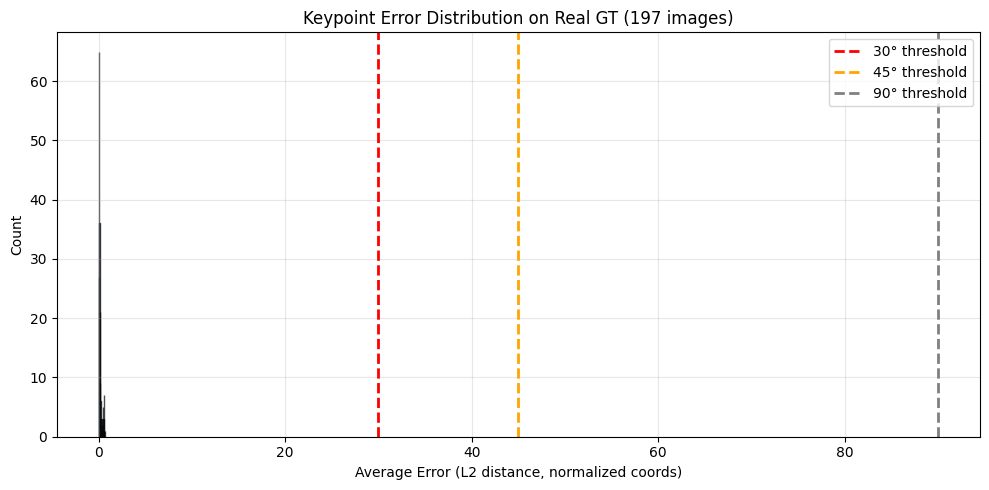

In [11]:
if errors:
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    plt.xlabel('Average Error (L2 distance, normalized coords)')
    plt.ylabel('Count')
    plt.title(f'Keypoint Error Distribution on Real GT ({len(errors)} images)')
    plt.axvline(x=30, color='red',    linestyle='--', linewidth=2, label='30° threshold')
    plt.axvline(x=45, color='orange', linestyle='--', linewidth=2, label='45° threshold')
    plt.axvline(x=90, color='gray',   linestyle='--', linewidth=2, label='90° threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

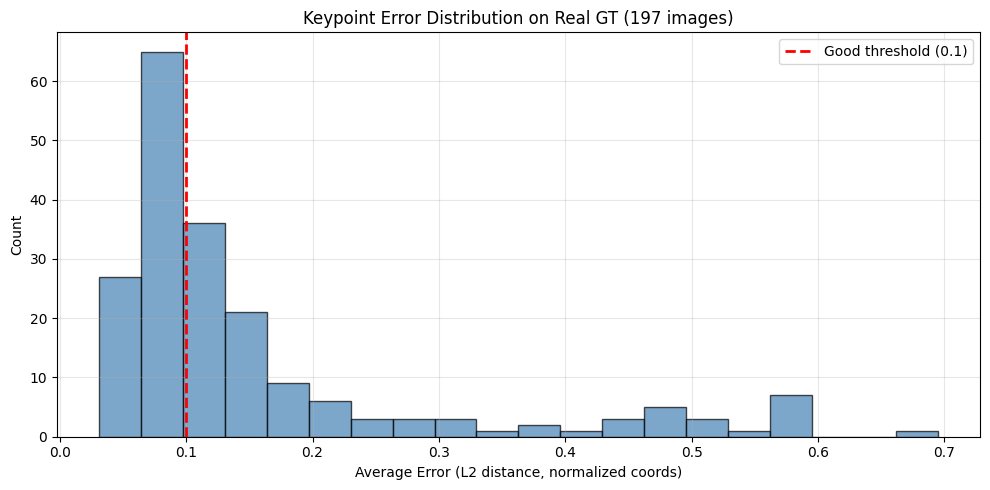

In [ ]:
# to get a better insight
if errors:
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    plt.xlabel('Average Error (L2 distance, normalized coords)')
    plt.ylabel('Count')
    plt.title(f'Keypoint Error Distribution on Real GT ({len(errors)} images)')
    plt.axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Good threshold (0.1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()